# Compression adaptative tissu / fond

Principe : segmenter le tissu sur la vignette basse résolution, remplacer le fond par du blanc pur sur l'image complète, puis recompresser.

Objectif : comparer la taille avec le notebook 2 (compression classique uniforme).

In [2]:
from pathlib import Path
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd
import openslide
import pyvips
from scipy import ndimage

DATA_DIR = Path("/Users/nath/Desktop/data_stage")
OUT_DIR = Path("./expe_debut_stage")
OUT_DIR.mkdir(exist_ok=True)

svs_files = sorted(DATA_DIR.glob("*.svs"), key=lambda p: p.stat().st_size)
SVS_PATH = svs_files[50]
orig_size = SVS_PATH.stat().st_size
print("Fichier :", SVS_PATH.name)
print("Taille originale :", round(orig_size / (1024*1024), 1), "Mo")

Fichier : TCGA-CD-A486-01Z-00-DX1.6FFE81CA-9074-44BC-B619-85A73BA61A2D.svs
Taille originale : 857.5 Mo


## 1. Chargement de la vignette et segmentation tissu/fond

In [3]:
slide = openslide.OpenSlide(str(SVS_PATH))

# On prend le dernier niveau (le plus petit) pour la segmentation rapide
last_level = slide.level_count - 1
thumb_w, thumb_h = slide.level_dimensions[last_level]
thumb = slide.read_region((0, 0), last_level, (thumb_w, thumb_h)).convert("RGB")
thumb_np = np.array(thumb)

print(f"Vignette niveau {last_level} : {thumb_np.shape}")

# 1. Fond blanc : pixels très clairs
mask_white = (thumb_np[:,:,0] >= 200) & (thumb_np[:,:,1] >= 200) & (thumb_np[:,:,2] >= 200)

# 2. Zones grises (R,G,B proches) = ombres ou fond
rgb_max = thumb_np.max(axis=2)
rgb_min = thumb_np.min(axis=2)
mask_gray = (rgb_max - rgb_min) <= 15

# 3. Fond = blanc OU gris
mask_background = mask_white | mask_gray
mask_tissue = ~mask_background

# Nettoyage morphologique : supprimer les petits objets de bruit
labeled, num_features = ndimage.label(mask_tissue)
sizes = ndimage.sum(mask_tissue, labeled, range(num_features + 1))
min_size = 500  # pixels dans la vignette
mask_clean = sizes[labeled] >= min_size
mask_tissue_clean = mask_clean & mask_tissue

# Remplir les petits trous dans le tissu
mask_tissue_final = ndimage.binary_fill_holes(mask_tissue_clean)

tissue_pct = mask_tissue_final.sum() / mask_tissue_final.size * 100
print(f"\nTissu : {tissue_pct:.1f}% | Fond : {100 - tissue_pct:.1f}%")

Vignette niveau 3 : (2755, 2112, 3)

Tissu : 37.8% | Fond : 62.2%


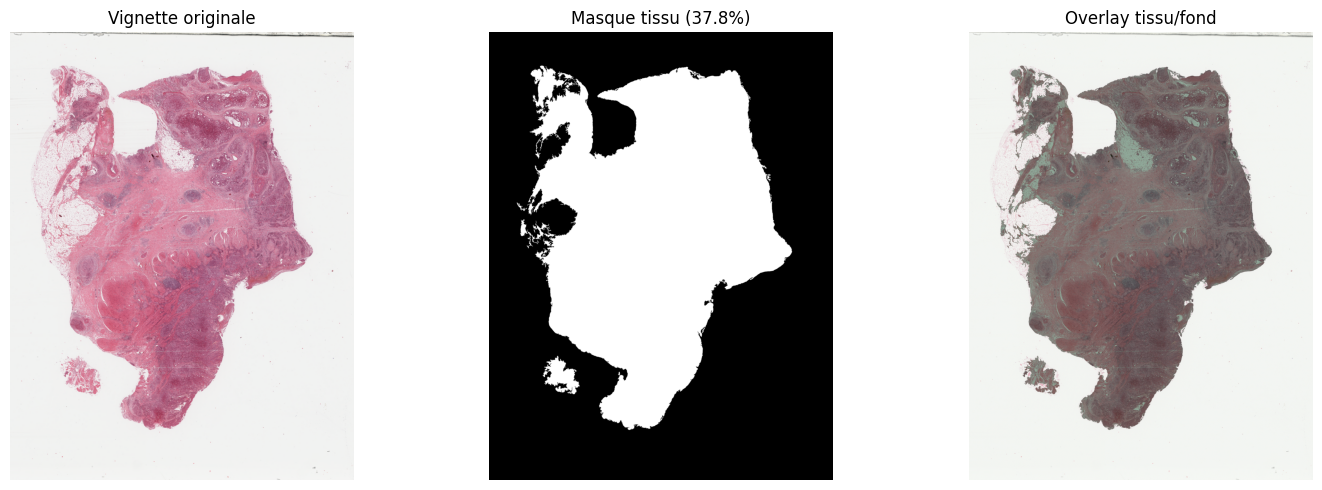

In [4]:
# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(thumb_np)
axes[0].set_title("Vignette originale")
axes[0].axis("off")
axes[1].imshow(mask_tissue_final, cmap="gray")
axes[1].set_title(f"Masque tissu ({tissue_pct:.1f}%)")
axes[1].axis("off")
axes[2].imshow(thumb_np)
axes[2].imshow(mask_tissue_final, cmap="Greens", alpha=0.4)
axes[2].set_title("Overlay tissu/fond")
axes[2].axis("off")
plt.tight_layout()
plt.show()

## 2. Compression adaptative : fond blanc pur + recompression JPEG

On utilise pyvips pour appliquer le masque redimensionné à la résolution complète.

In [5]:
def compress_adaptive(svs_path: Path, out_dir: Path, mask_lowres: np.ndarray, quality: int):
    """Compresse une lame en remplaçant le fond par du blanc pur."""
    out_path = out_dir / f"{svs_path.stem}_adaptive_q{quality}.tiff"
    
    img = pyvips.Image.new_from_file(str(svs_path))
    
    # Garder seulement RGB (les SVS peuvent avoir un canal alpha)
    if img.bands == 4:
        img = img.extract_band(0).bandjoin([img.extract_band(1), img.extract_band(2)])
    elif img.bands == 2:
        img = img.extract_band(0)
    
    print(f"  Image source : {img.width}x{img.height}, {img.bands} canaux")
    
    # Masque basse résolution 
    mask_low = pyvips.Image.new_from_array(mask_lowres.astype(np.uint8) * 255)
    
    # Redimensionner le masque à la résolution de l'image complète
    scale_x = img.width / mask_low.width
    scale_y = img.height / mask_low.height
    mask_full = mask_low.resize(scale_x, vscale=scale_y, kernel="nearest")
    
    # ifthenelse : si mask != 0 (tissu) → garder pixel original, sinon → blanc
    result = mask_full.ifthenelse(img, [255, 255, 255])
    
    # Sauvegarde TIFF pyramidal JPEG
    t0 = time.perf_counter()
    result.tiffsave(
        str(out_path),
        tile=True, tile_width=256, tile_height=256,
        pyramid=True,
        compression="jpeg",
        Q=quality
    )
    dt = time.perf_counter() - t0
    
    size = out_path.stat().st_size
    ratio = orig_size / size
    
    print(f"  Taille  : {size/(1024*1024):.1f} Mo")
    print(f"  Ratio   : {ratio:.2f}x (vs original)")
    print(f"  Temps   : {dt:.1f} s")
    
    return {
        "methode": f"ADAPTIF Q={quality}",
        "qualite": quality,
        "taille_Mo": round(size/(1024*1024), 1),
        "ratio": round(ratio, 2),
        "temps_s": round(dt, 1),
        "tissu_pct": round(tissue_pct, 1)
    }

## 3. Tests adaptatifs

In [6]:
results = []

# Original (ref)
results.append({
    "methode": "ORIGINAL SVS",
    "qualite": None,
    "taille_Mo": round(orig_size/(1024*1024), 1),
    "ratio": 1.0,
    "temps_s": 0.0,
    "tissu_pct": round(tissue_pct, 1)
})

# Adaptatif Q=90
results.append(compress_adaptive(SVS_PATH, OUT_DIR, mask_tissue_final, 90))

# Adaptatif Q=80
results.append(compress_adaptive(SVS_PATH, OUT_DIR, mask_tissue_final, 80))

# Adaptatif Q=70
results.append(compress_adaptive(SVS_PATH, OUT_DIR, mask_tissue_final, 70))

# Adaptatif Q=60
results.append(compress_adaptive(SVS_PATH, OUT_DIR, mask_tissue_final, 60))

# Adaptatif Q=50
results.append(compress_adaptive(SVS_PATH, OUT_DIR, mask_tissue_final, 50))

  Image source : 67591x88187, 3 canaux
  Taille  : 2369.0 Mo
  Ratio   : 0.36x (vs original)
  Temps   : 22.4 s
  Image source : 67591x88187, 3 canaux
  Taille  : 730.3 Mo
  Ratio   : 1.17x (vs original)
  Temps   : 20.9 s
  Image source : 67591x88187, 3 canaux
  Taille  : 617.0 Mo
  Ratio   : 1.39x (vs original)
  Temps   : 20.2 s
  Image source : 67591x88187, 3 canaux
  Taille  : 547.4 Mo
  Ratio   : 1.57x (vs original)
  Temps   : 20.4 s
  Image source : 67591x88187, 3 canaux
  Taille  : 495.8 Mo
  Ratio   : 1.73x (vs original)
  Temps   : 20.2 s


## 4. Tableau comparatif et graphique

,methode,qualite,taille_Mo,ratio,temps_s,tissu_pct
0,ORIGINAL SVS,NaN,857.5,1.00,0.0,37.8
1,ADAPTIF Q=90,90.0,2369.0,0.36,22.4,37.8
2,ADAPTIF Q=80,80.0,730.3,1.17,20.9,37.8
3,ADAPTIF Q=70,70.0,617.0,1.39,20.2,37.8
4,ADAPTIF Q=60,60.0,547.4,1.57,20.4,37.8
5,ADAPTIF Q=50,50.0,495.8,1.73,20.2,37.8


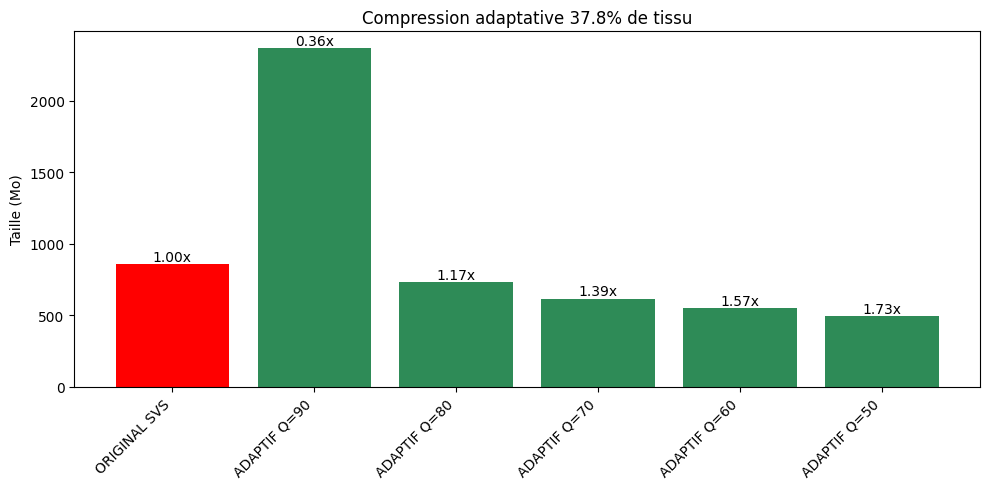

In [7]:
df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["red" if r == "ORIGINAL SVS" else "seagreen" for r in df["methode"]]
bars = ax.bar(df["methode"], df["taille_Mo"], color=colors)
ax.set_ylabel("Taille (Mo)")
ax.set_title(f"Compression adaptative {tissue_pct:.1f}% de tissu")

for bar, ratio in zip(bars, df["ratio"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f"{ratio:.2f}x", ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Comparaison avec la compression classique (notebook 2)


,methode,qualite,taille_Mo,ratio,temps_s,tissu_pct
0,ORIGINAL SVS,NaN,857.5,1.00,0.0,37.8
1,ADAPTIF Q=90,90.0,2369.0,0.36,22.4,37.8
2,ADAPTIF Q=80,80.0,730.3,1.17,20.9,37.8
3,ADAPTIF Q=70,70.0,617.0,1.39,20.2,37.8
4,ADAPTIF Q=60,60.0,547.4,1.57,20.4,37.8
5,ADAPTIF Q=50,50.0,495.8,1.73,20.2,37.8
6,CLASSIQUE Q=90,90.0,2546.7,0.88,NaN,NaN
7,CLASSIQUE Q=80,80.0,771.0,1.08,NaN,NaN
8,CLASSIQUE Q=70,70.0,646.6,1.26,NaN,NaN
9,CLASSIQUE Q=60,60.0,571.5,1.47,NaN,NaN


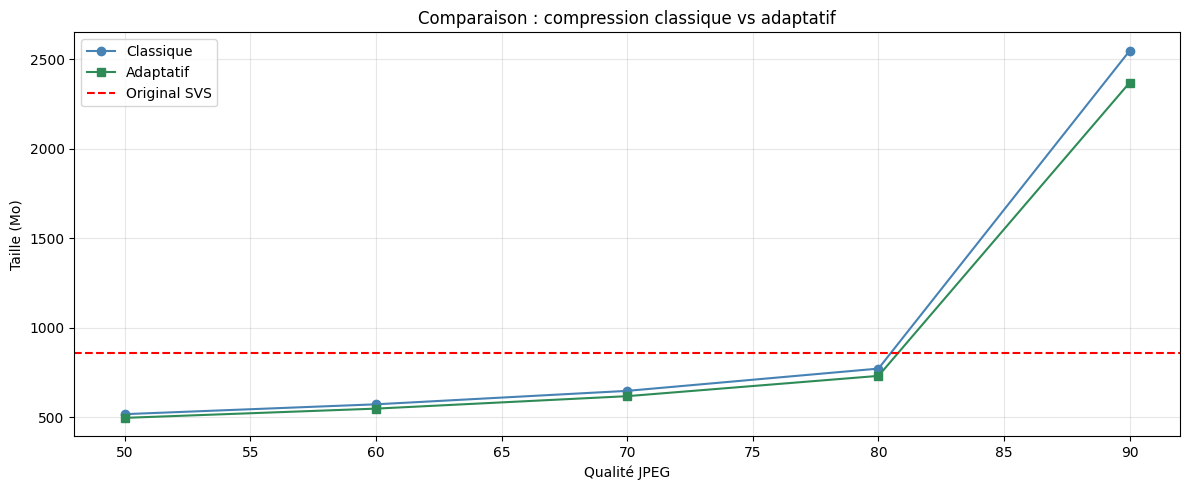

In [8]:
# ce sont les resultat du notebook 2, a refaire pour que ce soit direct exporté du notebook 2 parce qu e pas propre la
classic_results = [
    {"methode": "CLASSIQUE Q=90", "qualite": 90, "taille_Mo": 2546.7, "ratio": 0.88},
    {"methode": "CLASSIQUE Q=80", "qualite": 80, "taille_Mo": 771.0, "ratio": 1.08},
    {"methode": "CLASSIQUE Q=70", "qualite": 70, "taille_Mo": 646.6, "ratio": 1.26},
    {"methode": "CLASSIQUE Q=60", "qualite": 60, "taille_Mo": 571.5, "ratio": 1.47},
    {"methode": "CLASSIQUE Q=50", "qualite": 50, "taille_Mo": 516.5, "ratio": 1.69},
]

all_results = results + classic_results
df_all = pd.DataFrame(all_results)
display(df_all)

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 5))
classic = df_all[df_all["methode"].str.startswith("CLASSIQUE")]
adaptif = df_all[df_all["methode"].str.startswith("ADAPTIF")]

ax.plot(classic["qualite"], classic["taille_Mo"], "o-", label="Classique", color="steelblue")
ax.plot(adaptif["qualite"], adaptif["taille_Mo"], "s-", label="Adaptatif", color="seagreen")
ax.axhline(orig_size/(1024*1024), color="red", linestyle="--", label="Original SVS")

ax.set_xlabel("Qualité JPEG")
ax.set_ylabel("Taille (Mo)")
ax.set_title("Comparaison : compression classique vs adaptatif")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Vérification visuelle

On compare une zone de tissu entre l'original et le fichier adaptatif pour vérifier qu'il n'y a pas de perte visible sur les zones importantes.

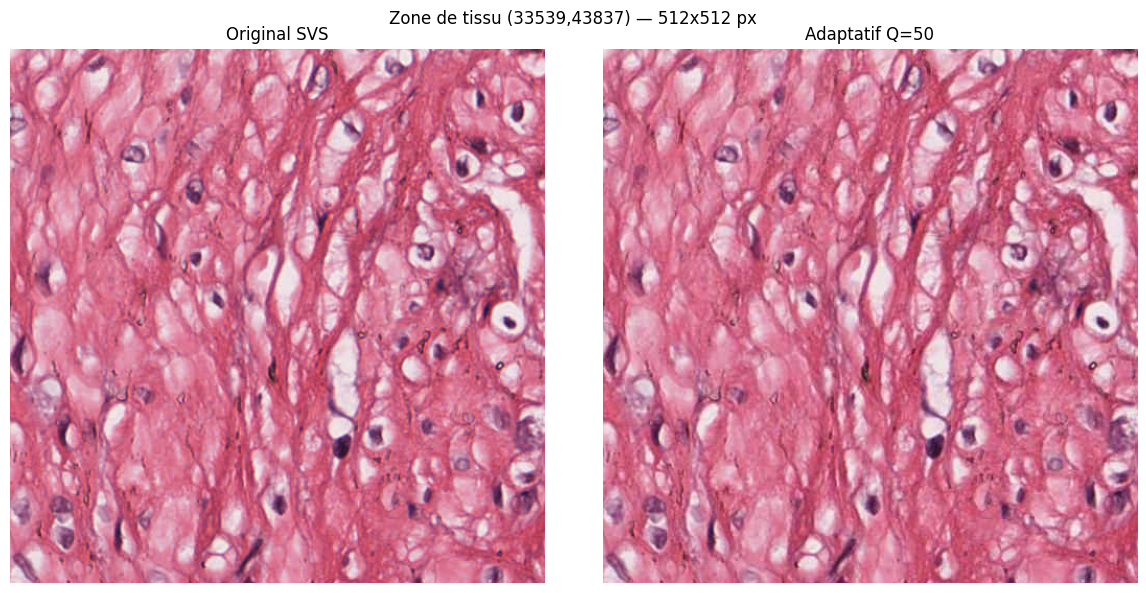

In [9]:
# Extraction d'une zone de tissu depuis l'original
REGION_SIZE = 512
w0, h0 = slide.level_dimensions[0]
cx = w0 // 2 - REGION_SIZE // 2
cy = h0 // 2 - REGION_SIZE // 2

region_orig = slide.read_region((cx, cy), 0, (REGION_SIZE, REGION_SIZE)).convert("RGB")

# On prend le fichier adaptatif avec le meilleur ratio (ex. Q=50)
adaptive_path = OUT_DIR / f"{SVS_PATH.stem}_adaptive_q50.tiff"
if adaptive_path.exists():
    slide_adapt = openslide.OpenSlide(str(adaptive_path))
    region_adapt = slide_adapt.read_region((cx, cy), 0, (REGION_SIZE, REGION_SIZE)).convert("RGB")
    slide_adapt.close()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(region_orig)
    axes[0].set_title("Original SVS")
    axes[0].axis("off")
    axes[1].imshow(region_adapt)
    axes[1].set_title("Adaptatif Q=50")
    axes[1].axis("off")
    plt.suptitle(f"Zone de tissu ({cx},{cy}) — {REGION_SIZE}x{REGION_SIZE} px")
    plt.tight_layout()
    plt.show()
else:
    print("Fichier adaptatif non trouvé. Lance d'abord la cellule de compression.")

In [10]:
slide.close()